In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [71]:
df=pd.read_csv("teleco.csv")

In [72]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Cleaning

In [73]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [74]:
df.drop(["customerID"],axis=1,inplace=True)

In [75]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [76]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [77]:
df["TotalCharges"].fillna(0,inplace=True)

C:\Users\sriva\AppData\Local\Temp\ipykernel_304\2201171674.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(0,inplace=True)


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [79]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [80]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


EDA

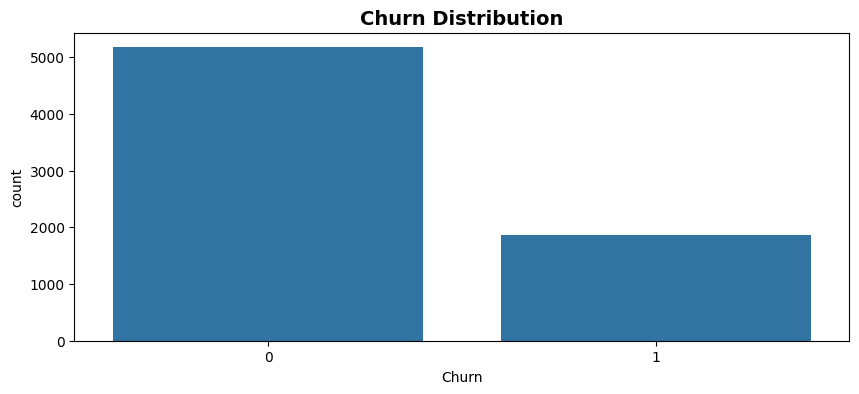

In [82]:
plt.figure(figsize=(10,4))
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution",fontsize=14,fontweight="bold")
plt.show()

it shows data is imbalanced and bias toward No but since the ratio is around 1:3 we donot need to do up or down sampling.We cannot see accuracy as metrics but can use recall and f1 score


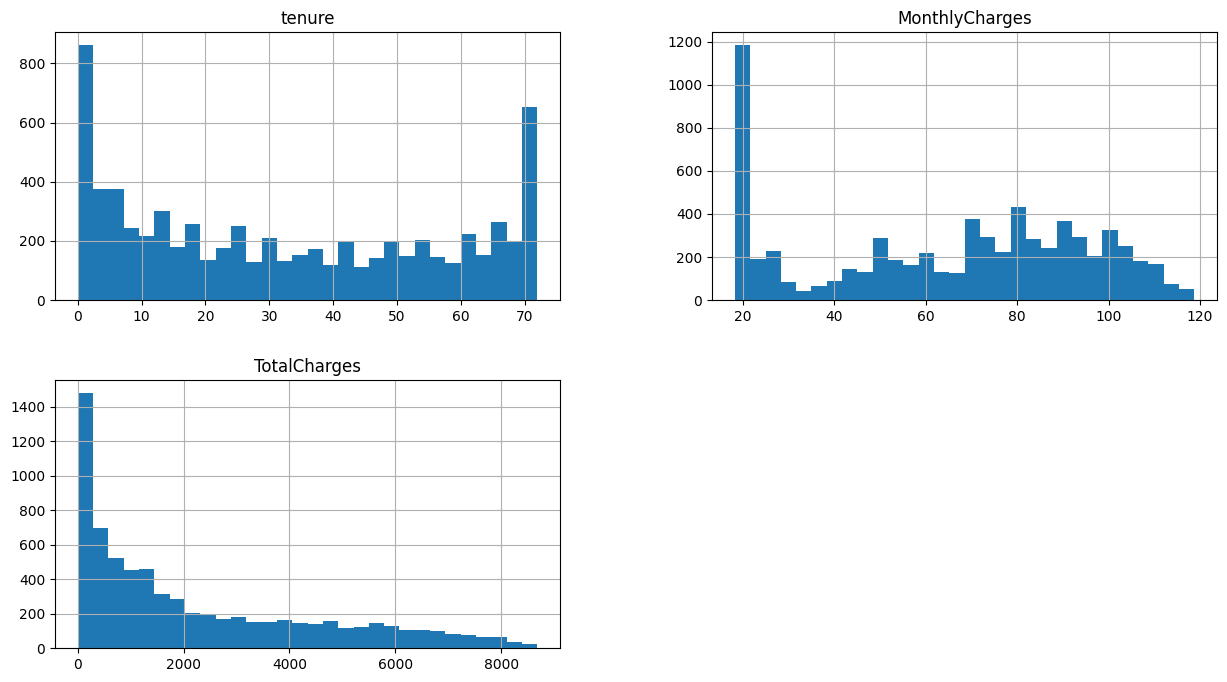

In [83]:

df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(bins=30, figsize=(15,8))
plt.show()

<Axes: xlabel='tenure', ylabel='Count'>

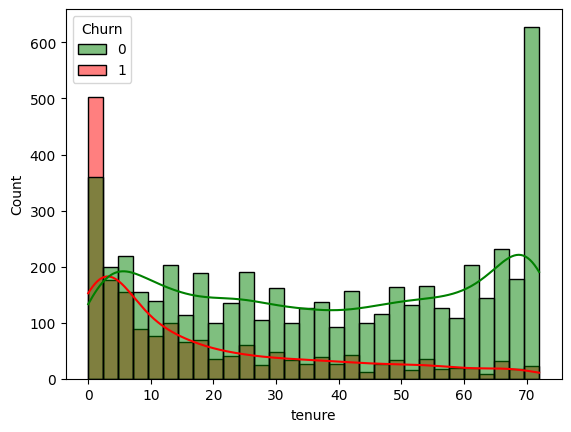

In [84]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True,
             palette=['green','red'])

INSIGHT: New customers (0-12 months) are at highest churn risk.


<Axes: xlabel='TotalCharges'>

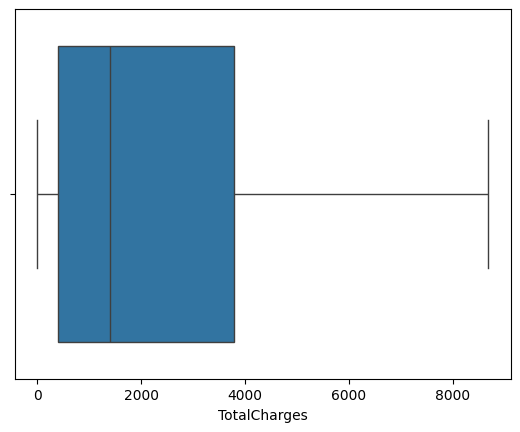

In [85]:
sns.boxplot(x=df["TotalCharges"])

Total charges feature is only skewd but donot contains outliers

<Axes: xlabel='TotalCharges', ylabel='Count'>

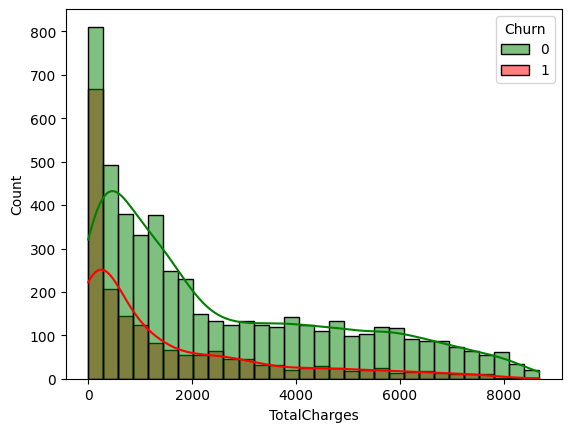

In [86]:
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30, kde=True,
             palette=['green','red'])

 Red and green curves separate clearly:
The feature is useful. But the skew means the model gives too much importance to the outliers on the right tail.


In [87]:
# Fix the skew with log transform
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

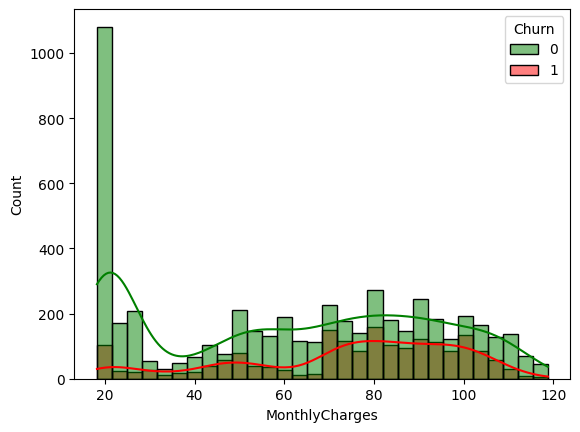

In [88]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True,
             palette=['green','red'])

In [89]:
# ── 1. tenure_group ───────────────────────────────────────────
def get_tenure_group(tenure):
    if tenure <= 10:   return 'Danger'        # red curve peaks here
    elif tenure <= 30: return 'Transition'    # red curve falling
    elif tenure <= 60: return 'Established'   # red near zero
    else:              return 'Loyal'         # green spikes here

df['tenure_group'] = df['tenure'].apply(get_tenure_group)

# ── 2. charge_group ───────────────────────────────────────────
def get_charge_group(charge):
    if charge < 30:    return 'Basic'         # giant spike at 20, near zero churn
    elif charge < 65:  return 'Mid'           # transition zone
    elif charge < 90:  return 'High_Risk'     # red curve peaks here
    else:              return 'Premium'       # both curves drop

df['charge_group'] = df['MonthlyCharges'].apply(get_charge_group)

# ── 3. Verify both created correctly ─────────────────────────
print('tenure_group counts:')
print(df['tenure_group'].value_counts())
print()
print('charge_group counts:')
print(df['charge_group'].value_counts())

tenure_group counts:
tenure_group
Established    1995
Danger         1970
Transition     1671
Loyal          1407
Name: count, dtype: int64

charge_group counts:
charge_group
High_Risk    2160
Premium      1744
Basic        1653
Mid          1486
Name: count, dtype: int64


In [90]:

df.drop(['tenure', 'MonthlyCharges'], axis=1, inplace=True)

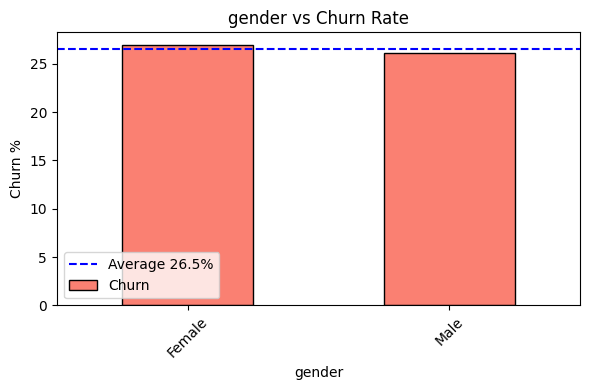

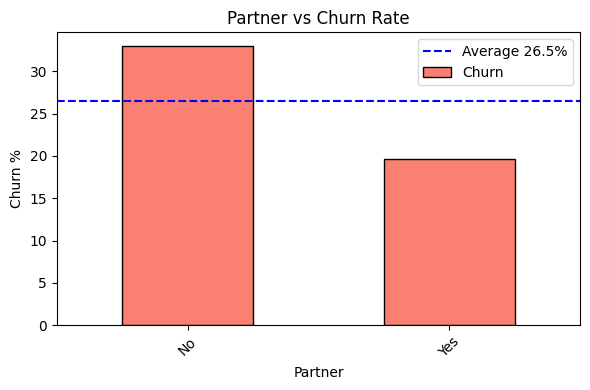

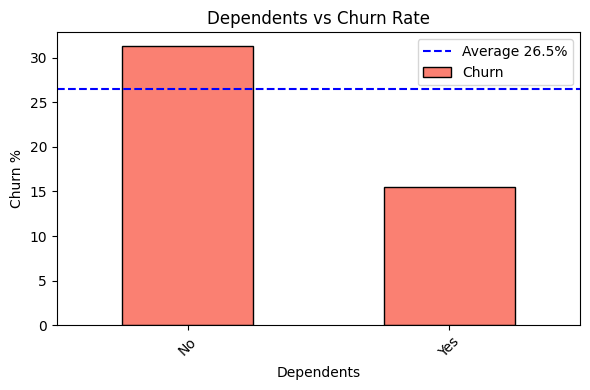

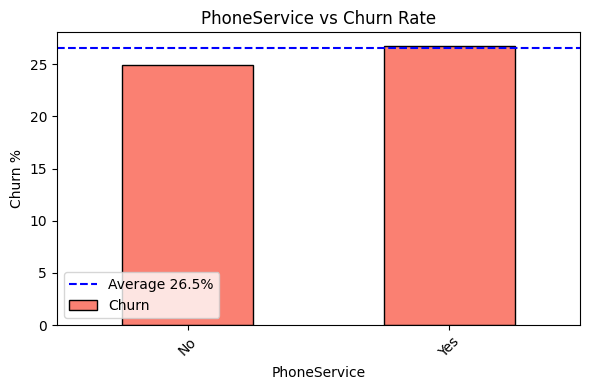

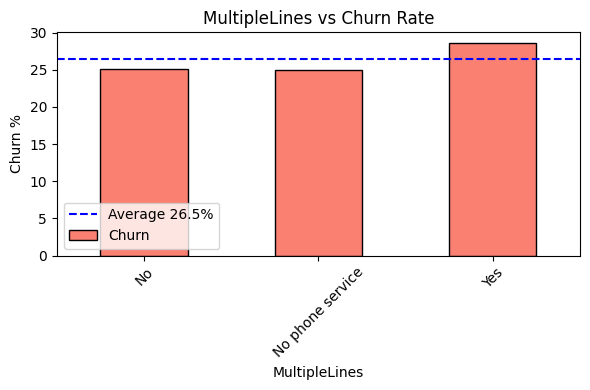

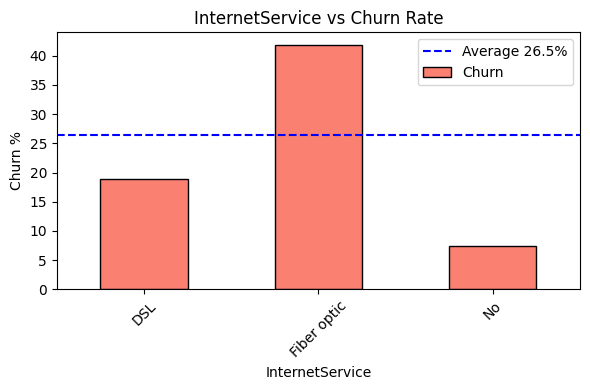

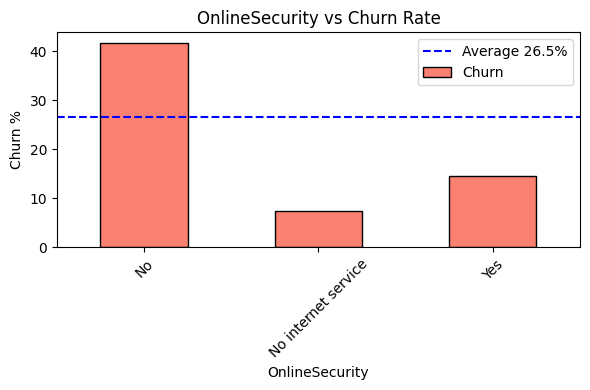

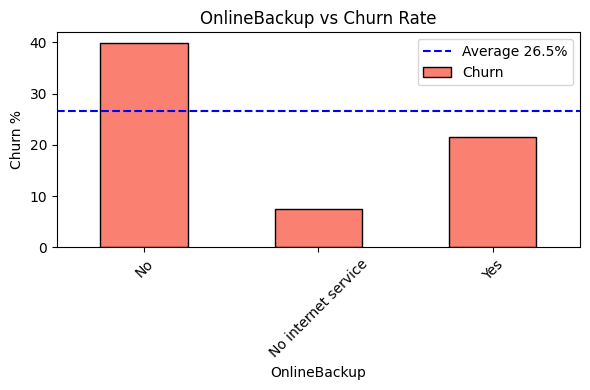

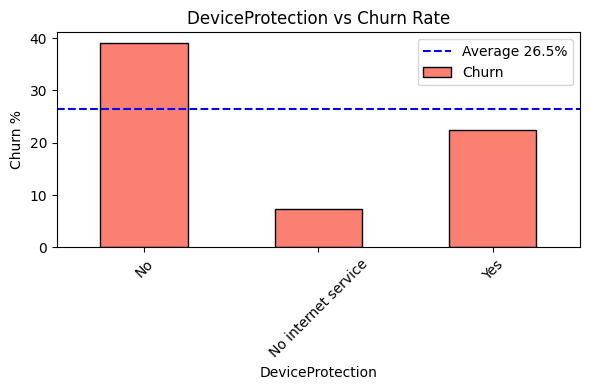

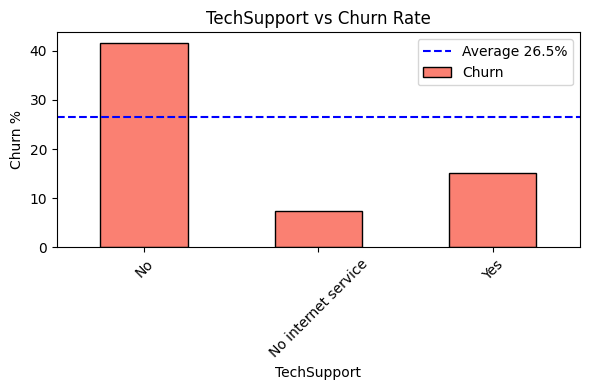

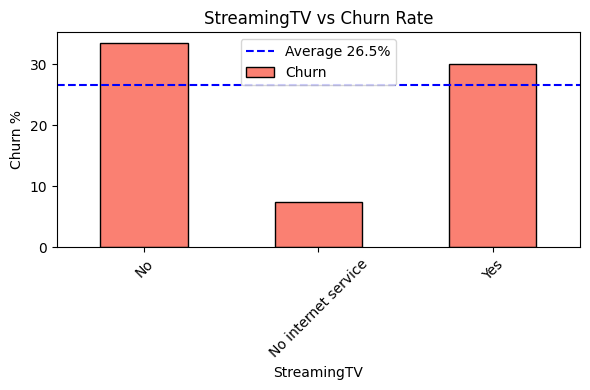

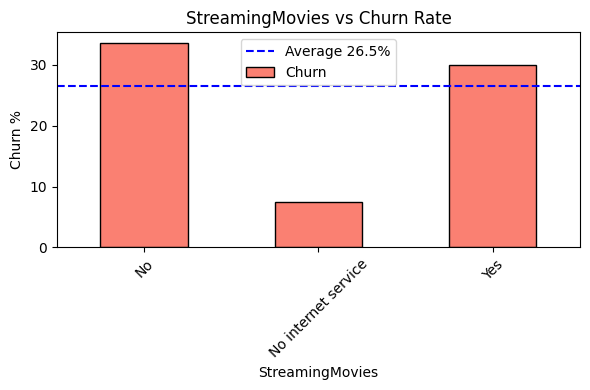

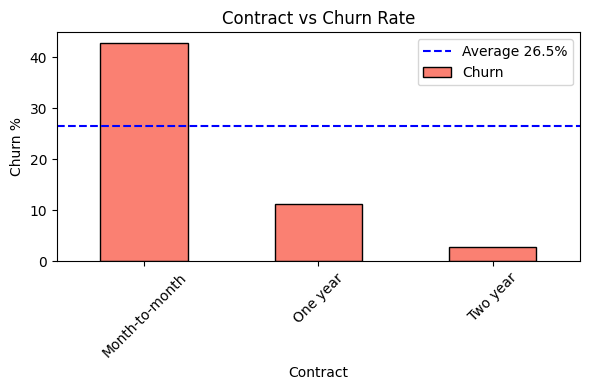

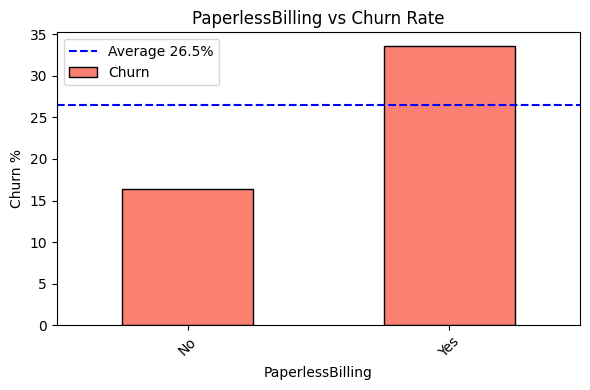

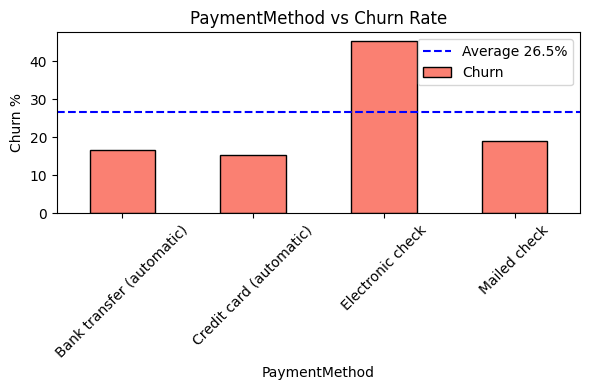

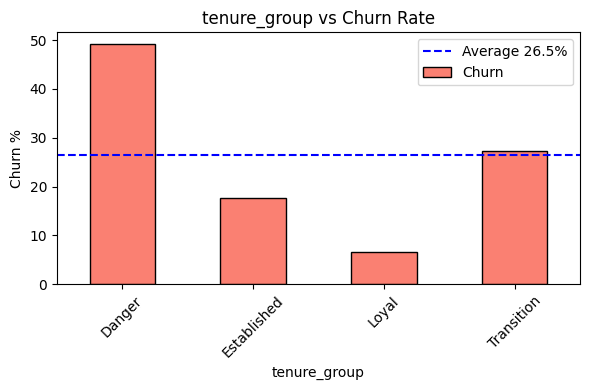

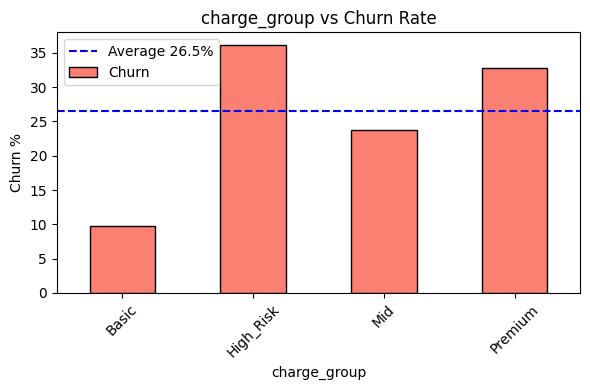

In [91]:
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean() * 100

    plt.figure(figsize=(6, 4))
    churn_rate.plot(kind='bar', color='salmon', edgecolor='black')
    plt.axhline(y=26.5, color='blue', linestyle='--', label='Average 26.5%')
    plt.title(f'{col} vs Churn Rate')
    plt.ylabel('Churn %')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [92]:
for col in cat_cols:
    print(f'\n{col}:')
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    print(churn_rate.round(1))
    print('Max diff:', round(churn_rate.max() - churn_rate.min(), 1), '%')
    print('---')


gender:
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64
Max diff: 0.8 %
---

Partner:
Partner
No     33.0
Yes    19.7
Name: Churn, dtype: float64
Max diff: 13.3 %
---

Dependents:
Dependents
No     31.3
Yes    15.5
Name: Churn, dtype: float64
Max diff: 15.8 %
---

PhoneService:
PhoneService
No     24.9
Yes    26.7
Name: Churn, dtype: float64
Max diff: 1.8 %
---

MultipleLines:
MultipleLines
No                  25.0
No phone service    24.9
Yes                 28.6
Name: Churn, dtype: float64
Max diff: 3.7 %
---

InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64
Max diff: 34.5 %
---

OnlineSecurity:
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64
Max diff: 34.4 %
---

OnlineBackup:
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn, dtype: float64
Max diff: 32.5 %


In [93]:
df.drop(columns=["gender","PhoneService","MultipleLines"],axis=1,inplace=True)

In [94]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport']

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')

In [95]:
# Streaming columns — No vs Yes almost identical after removing No internet service
df.drop(['StreamingTV', 'StreamingMovies'], axis=1, inplace=True)

In [96]:

df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

df['is_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)


df['is_alone'] = ((df['Partner'] == 'No') & 
                  (df['Dependents'] == 'No')).astype(int)

df['high_risk_combo'] = ((df['tenure_group'] == 'Danger') & 
                          (df['charge_group'].isin(['High_Risk','Premium']))).astype(int)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SeniorCitizen        7043 non-null   int64  
 1   Partner              7043 non-null   object 
 2   Dependents           7043 non-null   object 
 3   InternetService      7043 non-null   object 
 4   OnlineSecurity       7043 non-null   object 
 5   OnlineBackup         7043 non-null   object 
 6   DeviceProtection     7043 non-null   object 
 7   TechSupport          7043 non-null   object 
 8   Contract             7043 non-null   object 
 9   PaperlessBilling     7043 non-null   object 
 10  PaymentMethod        7043 non-null   object 
 11  TotalCharges         7043 non-null   float64
 12  Churn                7043 non-null   int64  
 13  TotalCharges_log     7043 non-null   float64
 14  tenure_group         7043 non-null   object 
 15  charge_group         7043 non-null   o

In [98]:
df.isnull().sum()

SeniorCitizen          0
Partner                0
Dependents             0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
Contract               0
PaperlessBilling       0
PaymentMethod          0
TotalCharges           0
Churn                  0
TotalCharges_log       0
tenure_group           0
charge_group           0
is_month_to_month      0
is_electronic_check    0
is_alone               0
high_risk_combo        0
dtype: int64

In [99]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Churn rate:', round(y.mean()*100, 2), '%')

X shape: (7043, 19)
y shape: (7043,)
Churn rate: 26.54 %


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Train churn rate:', round(y_train.mean()*100, 2), '%')
print('Test churn rate:', round(y_test.mean()*100, 2), '%')

X_train: (5634, 19)
X_test: (1409, 19)
Train churn rate: 26.54 %
Test churn rate: 26.54 %


In [101]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical = X.select_dtypes(include='object').columns.tolist()
numerical = X.select_dtypes(exclude='object').columns.tolist()


preprocessor = ColumnTransformer([
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False), categorical),
    ('scaler', StandardScaler(), numerical)
])

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)



In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',
                                               random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
                                             random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',
                                             random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=2.68,
                              random_state=42,
                              eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    print(f'\n{name}')
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.51      0.50      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.59      0.46      0.52       374

    accuracy                           0.77      1409
   macro avg       0.71      0.67      0.68      1409
weighted avg       0.76

In [103]:
lr_params = {'C':[0.01,0.1,1,10,100],'penalty':['l1','l2'],'solver':['liblinear','saga'],'class_weight':['balanced',None]}
dt_params = {'max_depth':[3,4,5,6,8,10],'min_samples_split':[2,5,10,20],'min_samples_leaf':[1,2,4,8],'class_weight':['balanced']}
rf_params = {'n_estimators':[100,200,300],'max_depth':[5,8,10,15],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'max_features':['sqrt','log2'],'class_weight':['balanced']}
xgb_params = {'n_estimators':[100,200,300],'max_depth':[3,4,5,6],'learning_rate':[0.01,0.05,0.1],'subsample':[0.7,0.8,1.0],'colsample_bytree':[0.7,0.8,1.0],'scale_pos_weight':[2.68],'reg_alpha':[0,0.1,0.5],'reg_lambda':[1,1.5,2]}

In [104]:
randomcv_models = [
    ("LR",LogisticRegression(),lr_params),
    ("DT",DecisionTreeClassifier(),dt_params),
                   ("RF", RandomForestClassifier(), rf_params),
    ("Xgboost", XGBClassifier(), xgb_params)
                   
                   ]

In [105]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=20,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1,error_score='raise'
)
    random.fit(X_train_processed, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits


e:\ML\yash\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\ML\yash\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
---------------- Best Params for LR -------------------
{'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': 0.1}
---------------- Best Params for DT -------------------
{'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 10, 'class_weight': 'balanced'}
---------------- Best Params for RF -------------------
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced'}
---------------- Best Params for Xgboost -------------------
{'subsample': 0.7, 'scale_pos_weight': 2.68, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [106]:
best_models = {

    'Logistic Regression': LogisticRegression(
        solver='liblinear',
        penalty='l1',
        class_weight=None,
        C=0.1,
        random_state=42,
        max_iter=1000
    ),

    'Decision Tree': DecisionTreeClassifier(
        min_samples_split=2,
        min_samples_leaf=8,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        subsample=0.7,
        scale_pos_weight=2.68,
        reg_lambda=1.5,
        reg_alpha=0.5,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=1.0,
        random_state=42,
        eval_metric='logloss'
    )
}


for name, model in best_models.items():
    
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    print(f'\n{"-"*10} {name} {"-"*10}')
    print(classification_report(y_test, y_pred))

e:\ML\yash\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\ML\yash\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



---------- Logistic Regression ----------
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


---------- Decision Tree ----------
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      1035
           1       0.47      0.72      0.57       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.77      0.71      0.72      1409


---------- Random Forest ----------
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro av

Since the dataset was imbalanced, Recall and F1-score for the churn class were prioritized over accuracy. After hyperparameter tuning, XGBoost achieved the best performance with a Recall of 0.76 and an F1-score of 0.62, making it the most suitable model for churn prediction.

In [107]:
import pickle


with open('xgboost_churn_model.pkl', 'wb') as file:
    pickle.dump(model, file)